# Datalab 4: Gravity regressions

The goal of this this Datalab is to introduce you to one of the workhorse models in international economics: the gravity model. The name comes from an analogy with Newton's Law of Gravitation. There, gravity obeys the following relationship:

$$
F_{ij} \;=\; G\,\frac{m_i\,m_j}{r_{ij}^{\,2}}
$$

where $m_i, m_j$: physical masses; $r_{ij}$: distance between objects; $G$: universal gravitational constant. In trade, since the 1960s researchers have observed that the value of trade between two countries obey the following pattern:

$$
X_{ij} \;=\; K \,\frac{Y_i\,Y_j}{d_{ij}^{\,\theta}}
$$

where $Y_i, Y_j$: \emph{economic masses} (GDP/total expenditure); $d_{ij}$: bilateral distance (proxy for trade costs); $\theta>0$: trade‐cost elasticity (empirical); $K$: scaling constant / fixed effects.

We saw in class that, with Cobb Douglas preferences, shipments from country $s$ do country $d$ obey:

$$
Q_{M,s\to d} = 
\alpha_d \frac{w_d L_d}{\tau_{s\to d}\, a_{C,s}\, w_s} =  \underbrace{\frac{1}{ a_{M,s}\, w_s}}_{\text{source factors}} \times \underbrace{\alpha_d w_d L_d}_{\text{destination factors}} \times \underbrace{\frac{1}{\tau_{s\to d}}}_{\text{bilateral trade costs}}
$$

and, in general, flows satisfy:

$$
\underbrace{X_{sd}}_{\substack{\text{trade flows}\\ \text{from s to d} }} \propto \frac{\underbrace{\omega_{s}}_{\text{source factors}} \times \underbrace{\gamma_{d}}_{\text{destination factors}}}{\underbrace{\tau_{sd}^{\theta}}_{\text{bilateral trade costs}}} 
$$

In this lab, we will first plot trade flows against distance. We will also run a univariate regression, motivating why we are doing so. Then I will ask you to include additional variables and see how they influence trade flows.

First, let us load the necessary packages and the dataset:

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from linearmodels import PanelOLS

# you will need to replace this path with the one in your own machine where you saved the
# dataset you downloaded from Canvas
data = r'C:\Users\cbezerradegoes\OneDrive\GWU\trade-undergrad\data\Gravity_V202102.dta'

In [2]:
# === Load data ===
df = pd.read_stata(data)

In [3]:
# === Inspect data ===
df

,year,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,gmt_offset_2020_d,contig,...,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d
0,1948,ABW,ABW,533.0,533.0,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1949,ABW,ABW,533.0,533.0,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1950,ABW,ABW,533.0,533.0,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1951,ABW,ABW,533.0,533.0,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1952,ABW,ABW,533.0,533.0,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4428283,2015,ZWE,ZWE,716.0,716.0,1,1,2.0,2.0,0.0,...,91.0,91.0,101.0,101.0,NaN,NaN,NaN,NaN,NaN,NaN
4428284,2016,ZWE,ZWE,716.0,716.0,1,1,2.0,2.0,0.0,...,91.0,91.0,101.0,101.0,NaN,NaN,NaN,NaN,NaN,NaN
4428285,2017,ZWE,ZWE,716.0,716.0,1,1,2.0,2.0,0.0,...,61.0,61.0,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN
4428286,2018,ZWE,ZWE,716.0,716.0,1,1,2.0,2.0,0.0,...,32.0,32.0,41.0,41.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# === Keep only pairs between existing countries ===
df = df[(df["country_exists_o"] == 1) & (df["country_exists_d"] == 1)].copy()
df

,year,iso3_o,iso3_d,iso3num_o,iso3num_d,country_exists_o,country_exists_d,gmt_offset_2020_o,gmt_offset_2020_d,contig,...,entry_time_o,entry_time_d,entry_tp_o,entry_tp_d,tradeflow_comtrade_o,tradeflow_comtrade_d,tradeflow_baci,manuf_tradeflow_baci,tradeflow_imf_o,tradeflow_imf_d
38,1986,ABW,ABW,533.0,533.0,1,1,-4.0,-4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,1987,ABW,ABW,533.0,533.0,1,1,-4.0,-4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
40,1988,ABW,ABW,533.0,533.0,1,1,-4.0,-4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41,1989,ABW,ABW,533.0,533.0,1,1,-4.0,-4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42,1990,ABW,ABW,533.0,533.0,1,1,-4.0,-4.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4428283,2015,ZWE,ZWE,716.0,716.0,1,1,2.0,2.0,0.0,...,91.0,91.0,101.0,101.0,NaN,NaN,NaN,NaN,NaN,NaN
4428284,2016,ZWE,ZWE,716.0,716.0,1,1,2.0,2.0,0.0,...,91.0,91.0,101.0,101.0,NaN,NaN,NaN,NaN,NaN,NaN
4428285,2017,ZWE,ZWE,716.0,716.0,1,1,2.0,2.0,0.0,...,61.0,61.0,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN
4428286,2018,ZWE,ZWE,716.0,716.0,1,1,2.0,2.0,0.0,...,32.0,32.0,41.0,41.0,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# === Check which columns exists ===
df.columns

Index(['year', 'iso3_o', 'iso3_d', 'iso3num_o', 'iso3num_d',
       'country_exists_o', 'country_exists_d', 'gmt_offset_2020_o',
       'gmt_offset_2020_d', 'contig', 'dist', 'distw', 'distcap', 'distwces',
       'dist_source', 'comlang_off', 'comlang_ethno', 'comcol', 'comrelig',
       'col45', 'legal_old_o', 'legal_old_d', 'legal_new_o', 'legal_new_d',
       'comleg_pretrans', 'comleg_posttrans', 'transition_legalchange',
       'heg_o', 'heg_d', 'col_dep_ever', 'col_dep', 'col_dep_end_year',
       'col_dep_end_conflict', 'empire', 'sibling_ever', 'sibling',
       'sever_year', 'sib_conflict', 'pop_o', 'pop_d', 'gdp_o', 'gdp_d',
       'gdpcap_o', 'gdpcap_d', 'pop_source_o', 'pop_source_d', 'gdp_source_o',
       'gdp_source_d', 'gdp_ppp_o', 'gdp_ppp_d', 'gdpcap_ppp_o',
       'gdpcap_ppp_d', 'pop_pwt_o', 'pop_pwt_d', 'gdp_ppp_pwt_o',
       'gdp_ppp_pwt_d', 'gatt_o', 'gatt_d', 'wto_o', 'wto_d', 'eu_o', 'eu_d',
       'rta', 'rta_coverage', 'rta_type', 'entry_cost_o', 'entry_cos

Here, 'tradeflow_comtrade_d' is the tradeflow recorded by the destination (imported) country as reported by UN Comtrade. Data are indexed by 'iso3_o', 'iso3_d' are country codes of the origin and destination countries; as well as by 'year', the period code. We will denote the trade flows as:

$$X_{od,t}$$

'distw' will be our metric for the distance between the two countries. Recall, gravity predicts that trade volumes are decreasing in trade flows $\tau_{od}$ and we assume that $\tau_{od}$ is increasing in the distance between the two countries. How can we 

First, let us log transform both variables:


In [6]:
# dependent variable
df["lntrade"] = np.log(df["tradeflow_comtrade_d"])
# independent variable
df["lndist"] = np.log(df["distw"])

We will estimate the following model:

$$
\ln X_{od,t} = \alpha + \beta \times \ln dist_{od} + e_{od,t}  
$$

In [7]:
gravity_simple = smf.ols("lntrade ~ lndist", data=df).fit()
print(gravity_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                lntrade   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                 4.804e+04
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:03:21   Log-Likelihood:            -2.5329e+06
No. Observations:              903272   AIC:                         5.066e+06
Df Residuals:                  903270   BIC:                         5.066e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.7957      0.044    379.461      0.0

Since this is a univariate regression, we can also plot a scatterplot showing the relationship

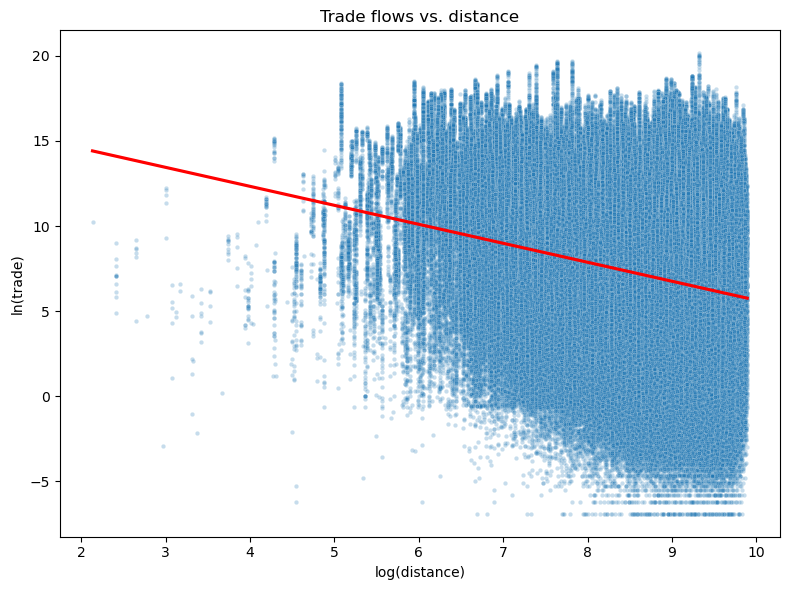

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="lndist", y="lntrade", data=df, alpha=0.25, s=10)
sns.regplot(x="lndist", y="lntrade", data=df, scatter=False, color="red")
plt.xlabel("log(distance)")
plt.ylabel("ln(trade)")
plt.title("Trade flows vs. distance")
plt.tight_layout()
plt.show()

Now let us include more variables.

In [9]:
# independent variables
df["lang"]   = df["comlang_off"]
df["leg"]    = df["transition_legalchange"]
df["relig"]  = df["comrelig"]
df["colony"] = df["col_dep_ever"]
df["border"] = df["contig"]

In [10]:
gravity = smf.ols("lntrade ~ lndist + lang + leg + relig + colony + border", data=df).fit()
print(gravity.summary())

                            OLS Regression Results                            
Dep. Variable:                lntrade   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                 1.036e+04
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        20:04:47   Log-Likelihood:            -2.3400e+06
No. Observations:              840167   AIC:                         4.680e+06
Df Residuals:                  840160   BIC:                         4.680e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.1121      0.051    317.166      0.0